# 34 - ReLU Variants

**Section:** Metaparameters | **Prereqs:** `Metaparameters/Activation_Functions.ipynb` | **Next:** `Metaparameters/LossFunctions.ipynb`

ReLU's one real flaw is the **dead unit**: once a unit's pre-activation is
negative for every input, its gradient is exactly zero, no update can change it,
and it is dead for the rest of training. The variants all patch that hole.

| Variant | Definition | Why |
|---|---|---|
| **ReLU** | `max(0, x)` | the default |
| **LeakyReLU** | `max(0.01x, x)` | small negative slope, so the gradient is never exactly zero - units cannot die |
| **ReLU6** | `min(max(0,x), 6)` | clipped above, keeps activations in a fixed range for quantised/mobile models |
| **ELU / GELU** | smooth negative tail | smoother gradients; GELU is what transformers use |

**What to expect from the comparison:** very little difference. On a shallow
network with well-scaled inputs, dead units are rare and every variant lands
within noise of the others. The variants earn their keep in deep networks -
which is worth knowing before spending a week tuning the activation.

**Each run is independent:** `train_model` constructs its own model and
optimizer, so the three variants start from identical conditions. Given how small
the differences are here, that matters - a confounded sweep would produce a gap
out of nothing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = wine_quality.data.features
y = wine_quality.data.targets

cols = X.columns

In [3]:
# Binarise wine quality at 5.
y['Bool Quality'] = y > 5
y['Bool Quality'] = y['Bool Quality'].astype(int)
y = y.drop('quality', axis=1)

/tmp/ipython-input-3-2717634329.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['Bool Quality'] = y > 5
/tmp/ipython-input-3-2717634329.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['Bool Quality'] = y['Bool Quality'].astype(int)


In [4]:
x = torch.tensor(X.to_numpy(),dtype=torch.float,device='cuda')
y = torch.tensor(y.to_numpy(),dtype=torch.float,device='cuda')


In [5]:
# Split, wrap, batch.
X_train, X_test, Y_train, Y_test = train_test_split(x,y , test_size=0.2)

train_data = TensorDataset(X_train,Y_train)
test_data = TensorDataset(X_test, Y_test)

bs = 32
train_loader = DataLoader(train_data,shuffle=True,batch_size=bs, drop_last=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])

In [11]:
# The activation is looked up in torch.nn by name and INSTANTIATED per forward
# pass - fine for parameterless activations, but note PReLU has a learned
# parameter and would be silently reset on every call.
class model(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(11,128)

    self.fc1 = nn.Linear(128,128)

    self.output_layer = nn.Linear(128,1)

  def forward(self,x, funcName):

    funcName = getattr(nn,funcName)()

    x = funcName(self.input_layer(x))

    x = funcName(self.fc1(x))

    return self.output_layer(x)

In [12]:
# Shared hyperparameters for the sweep. The MODEL and OPTIMIZER are deliberately
# NOT created here - see train_model below, which builds a fresh one per run so
# the activations are compared from identical starting conditions.
epochs = 1000
lr = 0.001
lossFunc = nn.BCEWithLogitsLoss()

In [13]:
# Training function taking the activation name.
# The model and optimizer are built INSIDE, so every call starts from fresh
# random weights - without that the runs would continue each other's training
# and the comparison would be meaningless.
def train_model(actFunc):
  Classifier = model().to('cuda')
  optimizer = torch.optim.SGD(Classifier.parameters(), lr=lr)

  test_acc = []
  train_acc = []
  losses = torch.zeros(epochs)

  for epoch in range(epochs):

    Classifier.train()
    batch_acc = []
    batch_loss = []

    for x,y in train_loader:

      yhat = Classifier.forward(x,actFunc)

      loss = lossFunc(yhat,y)
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # Test Train acc

      batch_acc.append( 100 * torch.mean( ((yhat > 0) == y).float()).item())

    train_acc.append(np.mean(batch_acc))
    losses[epoch] = np.mean(batch_loss)
    if epoch % 200 == 0 or epoch == epochs -1:
      print(f'{actFunc} : Epoch : {epoch} - Loss {losses[epoch]}')

    Classifier.eval()
    with torch.no_grad():
      X,Y =  next(iter(test_loader))
      preds = Classifier.forward(X,actFunc)
      test_acc.append(100 * torch.mean( ((preds>0) == Y).float()).item() )

  return test_acc, train_acc, losses

In [14]:
# ReLU vs ReLU6 vs LeakyReLU.
activation_funcs = ['ReLU', 'ReLU6','LeakyReLU']

In [15]:
# Three independent runs, each from a fresh model.
final_test = []
final_train = []
final_losses = []

for actfun in activation_funcs:
  test_acc, train_acc, losses = train_model(actfun)

  final_test.append(test_acc)
  final_train.append(train_acc)
  final_losses.append(losses)
  print()

ReLU : Epoch : 0 - Loss 0.8215250372886658
ReLU : Epoch : 200 - Loss 0.5594295859336853
ReLU : Epoch : 400 - Loss 0.5342350602149963
ReLU : Epoch : 600 - Loss 0.5280560851097107
ReLU : Epoch : 800 - Loss 0.5210295915603638
ReLU : Epoch : 999 - Loss 0.5145527720451355

ReLU6 : Epoch : 0 - Loss 0.5402755737304688
ReLU6 : Epoch : 200 - Loss 0.505476176738739
ReLU6 : Epoch : 400 - Loss 0.5040823221206665
ReLU6 : Epoch : 600 - Loss 0.49756601452827454
ReLU6 : Epoch : 800 - Loss 0.49030983448028564
ReLU6 : Epoch : 999 - Loss 0.4840180575847626

LeakyReLU : Epoch : 0 - Loss 0.598152756690979
LeakyReLU : Epoch : 200 - Loss 0.493118017911911
LeakyReLU : Epoch : 400 - Loss 0.49269402027130127
LeakyReLU : Epoch : 600 - Loss 0.4858885109424591
LeakyReLU : Epoch : 800 - Loss 0.4776751697063446
LeakyReLU : Epoch : 999 - Loss 0.477600634098053



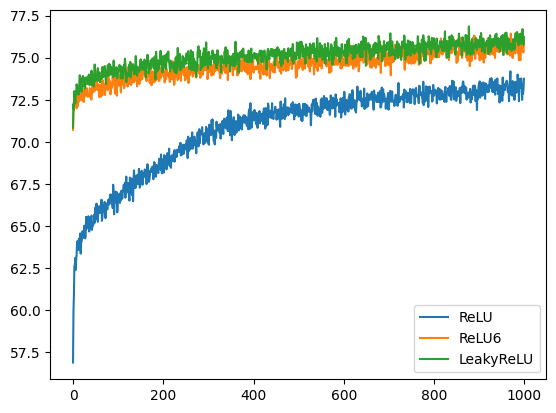

In [16]:
# Train accuracy per variant.
for i in range(3):
  plt.plot(final_train[i], label=activation_funcs[i])
  plt.legend();

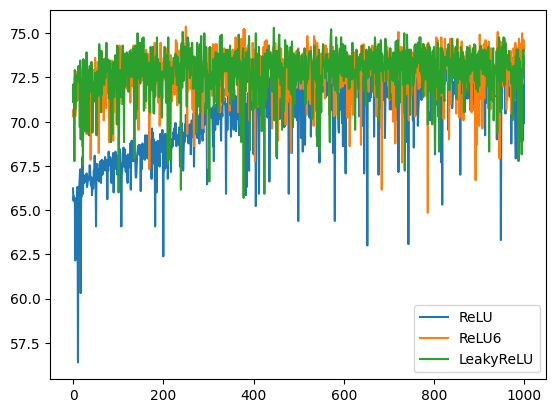

In [17]:
# Test accuracy per variant. Expect the lines to sit on top of each other -
# the honest finding is that this choice rarely matters at this depth.
for i in range(3):
  plt.plot(final_test[i], label=activation_funcs[i])
  plt.legend();

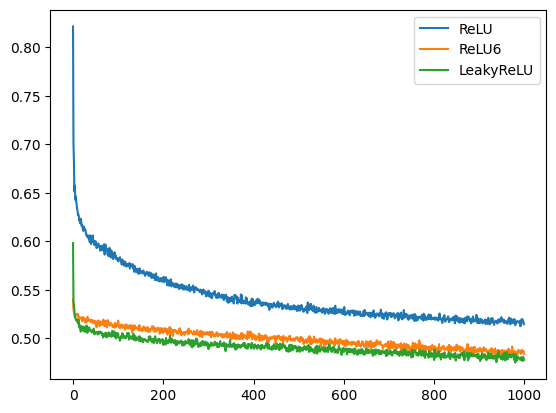

In [18]:
# Losses. Any difference here is small; re-run a few times before believing a
# gap this size, since single-run noise is comparable to it.
for i in range(3):
  plt.plot(final_losses[i], label=activation_funcs[i])
  plt.legend();